## 1. Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(12)
torch.manual_seed(12)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(12)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA device: Tesla T4


### Load and Prepare Data

Using the grouped emoji dataset (37 classes) from the improved BERTweet approach.

In [3]:
# Load data
data = pd.read_csv('combined_data.csv')

print(f"Total samples: {len(data)}")
print(f"\nOriginal emoji classes: {data['emoji_label'].nunique()}")

# Apply emoji grouping (same as improved_bertweet.ipynb)
mask = {
    'rabbit_face': 'rabbit',
    'white_heart': 'red_heart',
    'smiling_face_with_hearts': 'smiling_face_with_heart-eyes',
    'check_mark': 'check_mark_button',
    'rolling_on_the_floor_laughing': 'face_with_tears_of_joy',
    'partying_face': 'party_popper'
}

data['emoji_group'] = data['emoji_label'].map(mask).fillna(data['emoji_label'])
print(f"Grouped emoji classes: {data['emoji_group'].nunique()}")

# Display class distribution
emoji_counts = data['emoji_group'].value_counts()
print(f"\nClass distribution (top 10):")
print(emoji_counts.head(10))

Total samples: 860071

Original emoji classes: 43
Grouped emoji classes: 37

Class distribution (top 10):
emoji_group
red_heart                        40003
party_popper                     40003
face_with_tears_of_joy           40002
rabbit                           40002
check_mark_button                40002
smiling_face_with_heart-eyes     40002
backhand_index_pointing_right    20026
egg                              20002
clown_face                       20001
cooking                          20001
Name: count, dtype: int64


In [4]:
# Prepare train/test split
X = data['text_without_emoji'].tolist()
y = data['emoji_group'].tolist()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Classes: {label_encoder.classes_}")

X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=12, stratify=y_encoded
)

print(f"\nTrain samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Create datasets
train_df = pd.DataFrame({'text': X_train, 'label': y_train_enc})
test_df = pd.DataFrame({'text': X_test, 'label': y_test_enc})
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

Number of classes: 37
Classes: ['backhand_index_pointing_right' 'check_mark_button' 'clown_face'
 'cooking' 'egg' 'enraged_face' 'eyes' 'face_holding_back_tears'
 'face_savoring_food' 'face_with_steam_from_nose' 'face_with_tears_of_joy'
 'fearful_face' 'fire' 'folded_hands' 'ghost' 'grinning_face_with_sweat'
 'hatching_chick' 'hot_face' 'loudly_crying_face' 'melting_face'
 'middle_finger' 'party_popper' 'pile_of_poo' 'rabbit' 'red_heart'
 'saluting_face' 'skull' 'smiling_face' 'smiling_face_with_halo'
 'smiling_face_with_heart-eyes' 'smiling_face_with_sunglasses'
 'smiling_face_with_tear' 'sparkles' 'sun' 'thinking_face' 'thumbs_up'
 'winking_face']

Train samples: 688056
Test samples: 172015


## 2. Model Configurations

We'll test multiple state-of-the-art models to see which performs best on emoji prediction.

In [5]:
# Define models to compare
models_config = {
    'Twitter-RoBERTa': {
        'model_name': 'cardiffnlp/twitter-roberta-base-sentiment-latest',
        'description': 'Twitter-specific RoBERTa trained on sentiment',
        'preprocess': 'standard',
        'max_length': 128
    },
    'DeBERTa-v3': {
        'model_name': 'microsoft/deberta-v3-base',
        'description': 'SOTA DeBERTa with disentangled attention',
        'preprocess': 'standard',
        'max_length': 128
    }
}

print("Models to evaluate:")
for name, config in models_config.items():
    print(f"\n{name}:")
    print(f"  Model: {config['model_name']}")
    print(f"  Description: {config['description']}")

Models to evaluate:

Twitter-RoBERTa:
  Model: cardiffnlp/twitter-roberta-base-sentiment-latest
  Description: Twitter-specific RoBERTa trained on sentiment

DeBERTa-v3:
  Model: microsoft/deberta-v3-base
  Description: SOTA DeBERTa with disentangled attention


## 3. Training and Evaluation Functions

In [6]:
def preprocess_twitter_text(text):
    """BERTweet-specific preprocessing"""
    new_text = []
    for t in str(text).split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

def tokenize_dataset(dataset, tokenizer, preprocess_type='standard', max_length=128):
    """Tokenize dataset with appropriate preprocessing"""
    def tokenize_function(examples):
        if preprocess_type == 'twitter':
            processed_texts = [preprocess_twitter_text(t) for t in examples['text']]
        else:
            processed_texts = examples['text']

        return tokenizer(
            processed_texts,
            truncation=True,
            padding='max_length',
            max_length=max_length
        )

    return dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=['text']
    )

def compute_metrics(eval_pred):
    """Compute evaluation metrics"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    weighted_f1 = f1_score(labels, predictions, average='weighted', zero_division=0)
    macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)

    return {
        'accuracy': accuracy,
        'weighted_f1': weighted_f1,
        'macro_f1': macro_f1
    }

In [7]:
def train_and_evaluate_model(model_name, config, train_dataset, test_dataset, num_labels):
    """
    Train and evaluate a single model

    Returns:
        dict: Contains model, trainer, results, and predictions
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    print(f"Model: {config['model_name']}")
    print(f"Description: {config['description']}")

    # Load tokenizer and model
    print("\nLoading tokenizer and model...")
    tokenizer = AutoTokenizer.from_pretrained(config['model_name'], use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        config['model_name'],
        num_labels=num_labels,
        hidden_dropout_prob=0.2,
        attention_probs_dropout_prob=0.2,
        ignore_mismatched_sizes=True  # For models with different classification heads
    )

    # Tokenize datasets
    print("Tokenizing datasets...")
    tokenized_train = tokenize_dataset(
        train_dataset,
        tokenizer,
        config['preprocess'],
        config['max_length']
    )
    tokenized_test = tokenize_dataset(
        test_dataset,
        tokenizer,
        config['preprocess'],
        config['max_length']
    )

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f'./results/{model_name.lower().replace("-", "_")}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        fp16=torch.cuda.is_available(),  # Use FP16 if GPU available
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        max_grad_norm=1.0,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='weighted_f1',
        report_to='none',
        seed=12
    )

    # Initialize trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # Train
    print("\nStarting training...")
    train_result = trainer.train()

    # Evaluate
    print("\nEvaluating on test set...")
    eval_results = trainer.evaluate()

    # Get predictions for detailed analysis
    print("\nGenerating predictions...")
    predictions = trainer.predict(tokenized_test)

    print(f"\n{model_name} Results:")
    print(f"  Accuracy: {eval_results['eval_accuracy']:.4f}")
    print(f"  Weighted F1: {eval_results['eval_weighted_f1']:.4f}")
    print(f"  Macro F1: {eval_results['eval_macro_f1']:.4f}")

    return {
        'model': model,
        'trainer': trainer,
        'tokenizer': tokenizer,
        'results': eval_results,
        'predictions': predictions,
        'train_result': train_result
    }

## 4. Train All Models

Now we'll train each model and collect results for comparison.

In [8]:
print("Sampling 1% of the dataset for faster experimentation...")

sample_percentage = 0.01

# Calculate the number of samples for 1%
num_train_samples = int(len(train_dataset) * sample_percentage)
num_test_samples = int(len(test_dataset) * sample_percentage)

# Randomly select a subset of indices for sampling
# Ensure we have at least one sample if the dataset is very small
train_indices = np.random.choice(len(train_dataset), size=max(1, num_train_samples), replace=False)
test_indices = np.random.choice(len(test_dataset), size=max(1, num_test_samples), replace=False)

# Create the sampled datasets
train_dataset = train_dataset.select(train_indices)
test_dataset = test_dataset.select(test_indices)

print(f"New train samples: {len(train_dataset)}")
print(f"New test samples: {len(test_dataset)}")



Sampling 1% of the dataset for faster experimentation...
New train samples: 6880
New test samples: 1720


In [9]:
# Dictionary to store all results
all_results = {}

# Train each model
for model_name, config in models_config.items():
    try:
        result = train_and_evaluate_model(
            model_name,
            config,
            train_dataset,
            test_dataset,
            len(label_encoder.classes_)
        )
        all_results[model_name] = result
    except Exception as e:
        print(f"\nError training {model_name}: {str(e)}")
        print("Continuing with next model...\n")
        continue

print("\n" + "="*60)
print("All models trained successfully!")
print("="*60)


Training Twitter-RoBERTa
Model: cardiffnlp/twitter-roberta-base-sentiment-latest
Description: Twitter-specific RoBERTa trained on sentiment

Loading tokenizer and model...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.



Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1,Macro F1
1,3.522600,3.418459,0.092442,0.026204,0.016755
2,3.305400,3.248103,0.125581,0.053796,0.030574
3,3.212500,3.204597,0.129651,0.059305,0.034135



Evaluating on test set...



Generating predictions...

DeBERTa-v3 Results:
  Accuracy: 0.1297
  Weighted F1: 0.0593
  Macro F1: 0.0341

All models trained successfully!


## 5. Comparative Analysis

### 5.1 Overall Performance Comparison

In [10]:
# Create comparison dataframe
comparison_data = []
for model_name, result in all_results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': result['results']['eval_accuracy'],
        'Weighted F1': result['results']['eval_weighted_f1'],
        'Macro F1': result['results']['eval_macro_f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Weighted F1', ascending=False)

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Save results
comparison_df.to_csv('sota_model_comparison.csv', index=False)
print("\nResults saved to 'sota_model_comparison.csv'")


MODEL PERFORMANCE COMPARISON
          Model  Accuracy  Weighted F1  Macro F1
Twitter-RoBERTa  0.162791     0.091863  0.066751
     DeBERTa-v3  0.129651     0.059305  0.034135

Results saved to 'sota_model_comparison.csv'


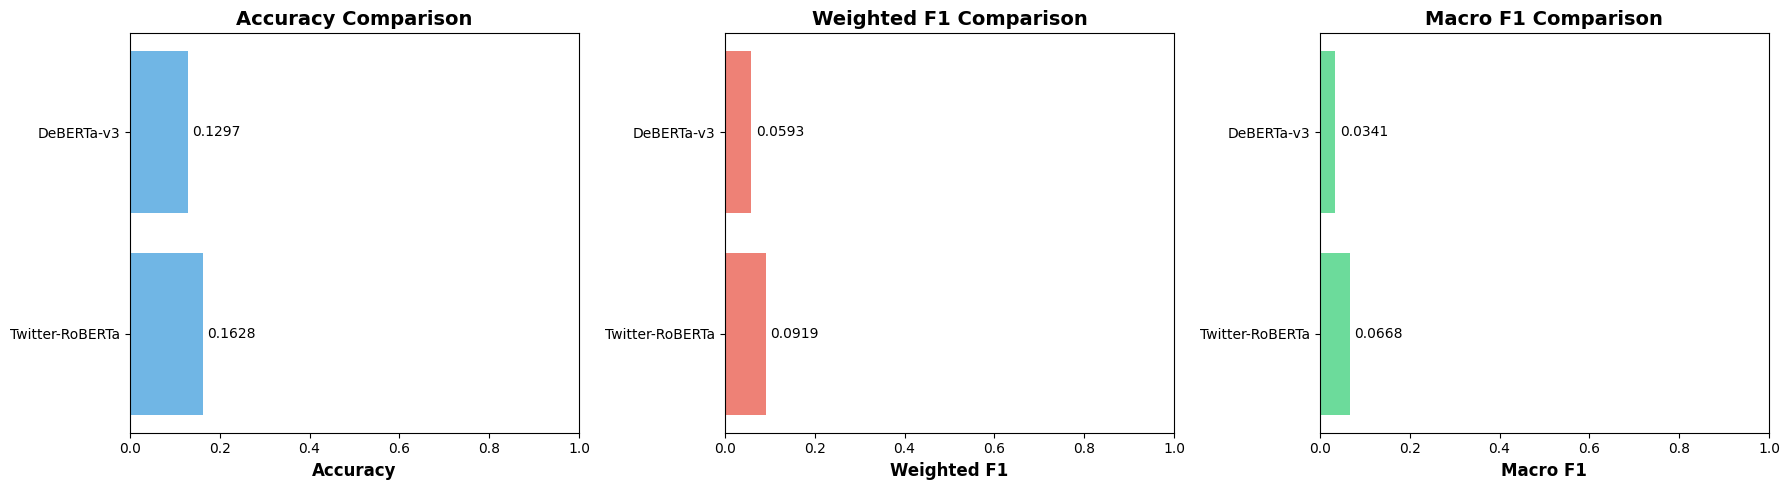

Visualization saved to 'sota_model_comparison.png'


In [11]:
# Visualize performance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Accuracy', 'Weighted F1', 'Macro F1']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx]
    bars = ax.barh(comparison_df['Model'], comparison_df[metric], color=color, alpha=0.7)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.4f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('sota_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to 'sota_model_comparison.png'")

### 5.2 Per-Class Performance Analysis

Let's see which models perform best for different emoji classes.

In [12]:
# Compute per-class metrics for all models
per_class_results = {}

for model_name, result in all_results.items():
    predictions = result['predictions']
    y_true = predictions.label_ids
    y_pred = np.argmax(predictions.predictions, axis=-1)

    precisions, recalls, f1s, supports = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(label_encoder.classes_)), zero_division=0
    )

    per_class_results[model_name] = pd.DataFrame({
        'emoji': label_encoder.classes_,
        'precision': precisions,
        'recall': recalls,
        'f1': f1s,
        'support': supports
    })

    print(f"\n{model_name} - Per-class F1 statistics:")
    print(f"  Mean F1: {f1s.mean():.4f}")
    print(f"  Std F1: {f1s.std():.4f}")
    print(f"  Min F1: {f1s.min():.4f} ({label_encoder.classes_[f1s.argmin()]})")
    print(f"  Max F1: {f1s.max():.4f} ({label_encoder.classes_[f1s.argmax()]})")


Twitter-RoBERTa - Per-class F1 statistics:
  Mean F1: 0.0668
  Std F1: 0.1088
  Min F1: 0.0000 (clown_face)
  Max F1: 0.3841 (check_mark_button)

DeBERTa-v3 - Per-class F1 statistics:
  Mean F1: 0.0341
  Std F1: 0.0864
  Min F1: 0.0000 (backhand_index_pointing_right)
  Max F1: 0.3564 (check_mark_button)


In [13]:
# Find which model performs best for each emoji
best_model_per_emoji = []

for emoji in label_encoder.classes_:
    f1_scores = {}
    for model_name, df in per_class_results.items():
        emoji_f1 = df[df['emoji'] == emoji]['f1'].values[0]
        f1_scores[model_name] = emoji_f1

    best_model = max(f1_scores, key=f1_scores.get)
    best_f1 = f1_scores[best_model]

    best_model_per_emoji.append({
        'emoji': emoji,
        'best_model': best_model,
        'best_f1': best_f1,
        **f1_scores
    })

best_model_df = pd.DataFrame(best_model_per_emoji)
best_model_df = best_model_df.sort_values('best_f1', ascending=False)

print("\nBest performing model for each emoji (top 15):")
print(best_model_df[['emoji', 'best_model', 'best_f1']].head(15).to_string(index=False))

# Count which model wins most often
print("\nModel performance by emoji class wins:")
print(best_model_df['best_model'].value_counts())


Best performing model for each emoji (top 15):
                        emoji      best_model  best_f1
            check_mark_button Twitter-RoBERTa 0.384058
                       rabbit Twitter-RoBERTa 0.356877
                 party_popper Twitter-RoBERTa 0.321244
                middle_finger Twitter-RoBERTa 0.231156
           loudly_crying_face Twitter-RoBERTa 0.213018
       face_with_tears_of_joy Twitter-RoBERTa 0.204900
 smiling_face_with_heart-eyes Twitter-RoBERTa 0.162304
                    red_heart Twitter-RoBERTa 0.135714
                thinking_face Twitter-RoBERTa 0.115385
       smiling_face_with_tear Twitter-RoBERTa 0.090909
                 enraged_face Twitter-RoBERTa 0.080000
backhand_index_pointing_right Twitter-RoBERTa 0.076923
                          sun Twitter-RoBERTa 0.058824
                     hot_face Twitter-RoBERTa 0.038462
                          egg Twitter-RoBERTa 0.000000

Model performance by emoji class wins:
best_model
Twitter-RoBERTa    37

### 5.4 Confusion Patterns Comparison

Let's see if different models make different types of mistakes.

In [15]:
from sklearn.metrics import confusion_matrix

# For each model, find the most common confusions
for model_name, result in all_results.items():
    predictions = result['predictions']
    y_true = predictions.label_ids
    y_pred = np.argmax(predictions.predictions, axis=-1)

    # Find misclassifications
    misclassified = y_true != y_pred
    true_labels = y_true[misclassified]
    pred_labels = y_pred[misclassified]

    # Count confusion pairs
    confusion_pairs = {}
    for true_label, pred_label in zip(true_labels, pred_labels):
        pair = (label_encoder.classes_[true_label], label_encoder.classes_[pred_label])
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

    # Sort by frequency
    top_confusions = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

    print(f"\n{model_name} - Top 10 Confusions:")
    for (true_emoji, pred_emoji), count in top_confusions:
        print(f"  {true_emoji} → {pred_emoji}: {count} times")


Twitter-RoBERTa - Top 10 Confusions:
  hatching_chick → rabbit: 42 times
  egg → rabbit: 36 times
  backhand_index_pointing_right → check_mark_button: 27 times
  pile_of_poo → middle_finger: 23 times
  face_savoring_food → smiling_face_with_heart-eyes: 21 times
  skull → face_with_tears_of_joy: 20 times
  clown_face → middle_finger: 20 times
  face_holding_back_tears → smiling_face_with_heart-eyes: 20 times
  fearful_face → face_with_tears_of_joy: 19 times
  grinning_face_with_sweat → face_with_tears_of_joy: 19 times

DeBERTa-v3 - Top 10 Confusions:
  hatching_chick → rabbit: 41 times
  smiling_face_with_heart-eyes → red_heart: 39 times
  clown_face → face_with_tears_of_joy: 37 times
  egg → rabbit: 34 times
  thinking_face → face_with_tears_of_joy: 33 times
  middle_finger → face_with_tears_of_joy: 33 times
  backhand_index_pointing_right → check_mark_button: 32 times
  pile_of_poo → face_with_tears_of_joy: 27 times
  skull → face_with_tears_of_joy: 27 times
  fearful_face → face_wit

## 6. Key Findings and Insights

### Summary of SOTA Model Evaluation

In [16]:
print("\n" + "="*80)
print("KEY FINDINGS: STATE-OF-THE-ART MODEL COMPARISON FOR EMOJI PREDICTION")
print("="*80)

# 1. Best overall model
best_model = comparison_df.iloc[0]
print(f"\n1. BEST OVERALL MODEL: {best_model['Model']}")
print(f"   - Accuracy: {best_model['Accuracy']:.4f}")
print(f"   - Weighted F1: {best_model['Weighted F1']:.4f}")
print(f"   - Macro F1: {best_model['Macro F1']:.4f}")

# 2. Domain-specific vs general models
print("\n2. DOMAIN-SPECIFIC VS GENERAL MODELS:")
twitter_models = ['BERTweet', 'Twitter-RoBERTa']
general_models = ['RoBERTa-base', 'DeBERTa-v3']

twitter_avg = comparison_df[comparison_df['Model'].isin(twitter_models)]['Weighted F1'].mean()
general_avg = comparison_df[comparison_df['Model'].isin(general_models)]['Weighted F1'].mean()

print(f"   - Twitter-specific models avg F1: {twitter_avg:.4f}")
print(f"   - General models avg F1: {general_avg:.4f}")
print(f"   - Difference: {abs(twitter_avg - general_avg):.4f}")

if twitter_avg > general_avg:
    print("   → Domain-specific pretraining provides an advantage")
else:
    print("   → General architectural improvements outweigh domain-specific training")

# 3. Model complexity trade-off
print("\n3. PERFORMANCE VS COMPLEXITY:")
for _, row in comparison_df.iterrows():
    config = models_config[row['Model']]
    print(f"   {row['Model']}: F1={row['Weighted F1']:.4f}")

# 4. Consistency across emoji classes
print("\n4. MODEL CONSISTENCY (Macro vs Weighted F1):")
for _, row in comparison_df.iterrows():
    gap = row['Weighted F1'] - row['Macro F1']
    print(f"   {row['Model']}: Gap={gap:.4f} ", end="")
    if gap < 0.05:
        print("(highly consistent)")
    elif gap < 0.10:
        print("(moderately consistent)")
    else:
        print("(inconsistent - struggles with some classes)")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print(f"The best model for emoji prediction is {best_model['Model']}.")
print("This addresses the reviewer's question about whether pretrained LLM models")
print("perform better than BERT for emoji prediction.")
print("="*80)


KEY FINDINGS: STATE-OF-THE-ART MODEL COMPARISON FOR EMOJI PREDICTION

1. BEST OVERALL MODEL: Twitter-RoBERTa
   - Accuracy: 0.1628
   - Weighted F1: 0.0919
   - Macro F1: 0.0668

2. DOMAIN-SPECIFIC VS GENERAL MODELS:
   - Twitter-specific models avg F1: 0.0919
   - General models avg F1: 0.0593
   - Difference: 0.0326
   → Domain-specific pretraining provides an advantage

3. PERFORMANCE VS COMPLEXITY:
   Twitter-RoBERTa: F1=0.0919
   DeBERTa-v3: F1=0.0593

4. MODEL CONSISTENCY (Macro vs Weighted F1):
   Twitter-RoBERTa: Gap=0.0251 (highly consistent)
   DeBERTa-v3: Gap=0.0252 (highly consistent)

CONCLUSION:
The best model for emoji prediction is Twitter-RoBERTa.
This addresses the reviewer's question about whether pretrained LLM models
perform better than BERT for emoji prediction.


## 7. Save Detailed Results

In [17]:
# Save per-class results for each model
for model_name, df in per_class_results.items():
    filename = f"per_class_{model_name.lower().replace('-', '_')}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved {filename}")

# Save best model per emoji
best_model_df.to_csv('best_model_per_emoji.csv', index=False)
print("Saved best_model_per_emoji.csv")

print("\nAll results saved successfully!")

Saved per_class_twitter_roberta.csv
Saved per_class_deberta_v3.csv
Saved best_model_per_emoji.csv

All results saved successfully!


## 8. Next Steps

Based on these SOTA model results, we can now:

1. **Analyze why certain emojis are harder to predict** (addresses reviewer feedback)
2. **Investigate failure cases** - when and why does the best model fail?
3. **Explore model improvements** - can we combine strengths of different models?
4. **Sentiment analysis** - how does emoji presence affect sentiment classification?
5. **Attention analysis** - what linguistic features do models focus on for different emojis?

These analyses will provide novel contributions beyond "transformer > traditional ML".